## Script for statistics of binary relevance and classifier chains of benchmarks


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import utils
import os
from sklearn.metrics import jaccard_score, roc_auc_score

In [2]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



In [22]:
#ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest", "Rakel_lr", "Rakel_xgb", "Rakel_forest"]

ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = ".csv"

sub_accs = {}

for path in filepath_list_ml:

    br_results = []
    cc_results = []
    #rakel_results = []

    for model in ml_models:
        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(pred_labels, true_labels)

        if model.startswith("BR"):
            br_results.append(sub_acc)
        elif model.startswith("CC"):
            cc_results.append(sub_acc)
        """
        else:
            rakel_results.append(sub_acc)
        """
    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results]})


df_sub_accs = pd.DataFrame(sub_accs)

print(sub_accs)

{'PI': [[0.6696165191740413, 0.6489675516224189, 0.6253687315634219], [0.6755162241887905, 0.6371681415929203, 0.640117994100295]], 'NNRTI': [[0.5172413793103449, 0.5344827586206896, 0.5689655172413793], [0.5344827586206896, 0.5689655172413793, 0.603448275862069]], 'NRTI': [[0.5533453887884268, 0.5515370705244123, 0.5316455696202531], [0.5605786618444847, 0.5768535262206148, 0.5443037974683544]], 'INI': [[0.6470588235294118, 0.5490196078431373, 0.6274509803921569], [0.6470588235294118, 0.5490196078431373, 0.6274509803921569]]}


In [23]:
files = ["Binary_Relevance_MOC_prediction.csv", "Binary_Relevance_homebrew_prediction.csv", "Classifier_Chain_homebrew_prediction.csv"]

sub_accs_tabpfn = {}
jacc_macro = {}


for path in filepath_list:

    acc_list = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(true_labels, pred_labels, nan_mode="ignore")

        #print(jaccard_score(true_labels, pred_labels, average="samples"))
        #print(jaccard_score(true_labels, pred_labels, average="macro"))
        acc_list.append(sub_acc)

    sub_accs_tabpfn.update({path.split("/")[-1].strip("_"):acc_list})

print(sub_accs_tabpfn)

{'PI': [0.6578171091445427, 0.6656716417910448, 0.6686567164179105], 'NNRTI': [0.6896551724137931, 0.6545454545454545, 0.7272727272727273], 'NRTI': [0.5732368896925859, 0.592057761732852, 0.6137184115523465], 'INI': [0.6274509803921569, 0.6181818181818182, 0.6727272727272727]}


In [ ]:
test1 = list(np.array(["1", "2"]))
test2 = list(np.array(["3", "4"]))

print(test1 + test2)

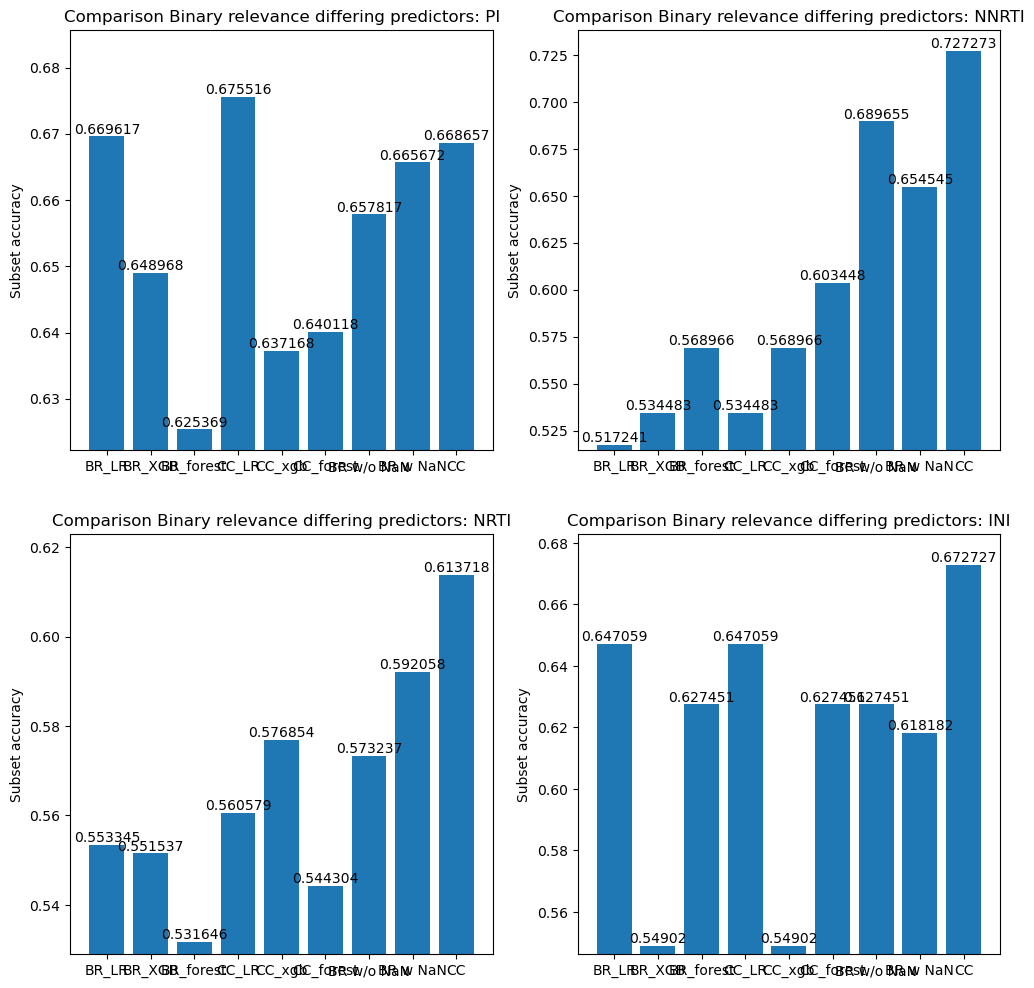

In [24]:
"""subset accuracy ignoring missing labels"""
"""
files = ["Binary_Relevance_MOC_prediction.csv", "Binary_Relevance_homebrew_prediction.csv", "Classifier_Chain_homebrew_prediction.csv"]

sub_accs = {}



for path in filepath_list_ml:

    acc_list = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(pred_labels, true_labels, nan_mode="ignore")

        acc_list.append(sub_acc)

    sub_accs.update({path.split("/")[-1].strip("_"):acc_list})



print(sub_accs)



file = "_results/Binary_complete_labels_Multilabel_prediction.csv"


#models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs_old = []

targets = ["PI", "NNRTI", "NRTI", "INI"]

for path, target in zip(filepath_list_ml, targets):

    df_old_ml_pred = pd.DataFrame()

    drugs = [file_name.strip("_results") for file_name in os.listdir(path) if "_results" in file_name]

    #acc_list = []


    for drug in drugs:
        results = pd.read_csv(path + drug + file)

        df_old_ml_pred["True_" + drug] = results["True"]

        #print(drug)

        df_old_ml_pred["Pred_" + drug] = [1.0 if proba >= 0.5 else 0.0 for proba in results["1"]]

    #print(df_old_ml_pred)

    true_labels = df_old_ml_pred.filter(regex="True_*")
    pred_labels = df_old_ml_pred.filter(regex="Pred_*")

    #print(true_labels)
    #print(pred_labels)

    sub_accs[target].append(utils.subset_acc(pred_labels, true_labels))

#print(sub_accs)

df_sub_accs = pd.DataFrame(sub_accs)
"""


models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):

    benchmarks = np.array(sub_accs[drug]).flatten()
    results = list(benchmarks) + sub_accs_tabpfn[drug]
    labels = ml_models + models_w_TabPFN
    p = axs[i].bar(labels, results)

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, min(results) * 0.995), min(1.0, max(results)  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)




#plt.savefig("../figures/BR_CC_comparison_woNaN.png")



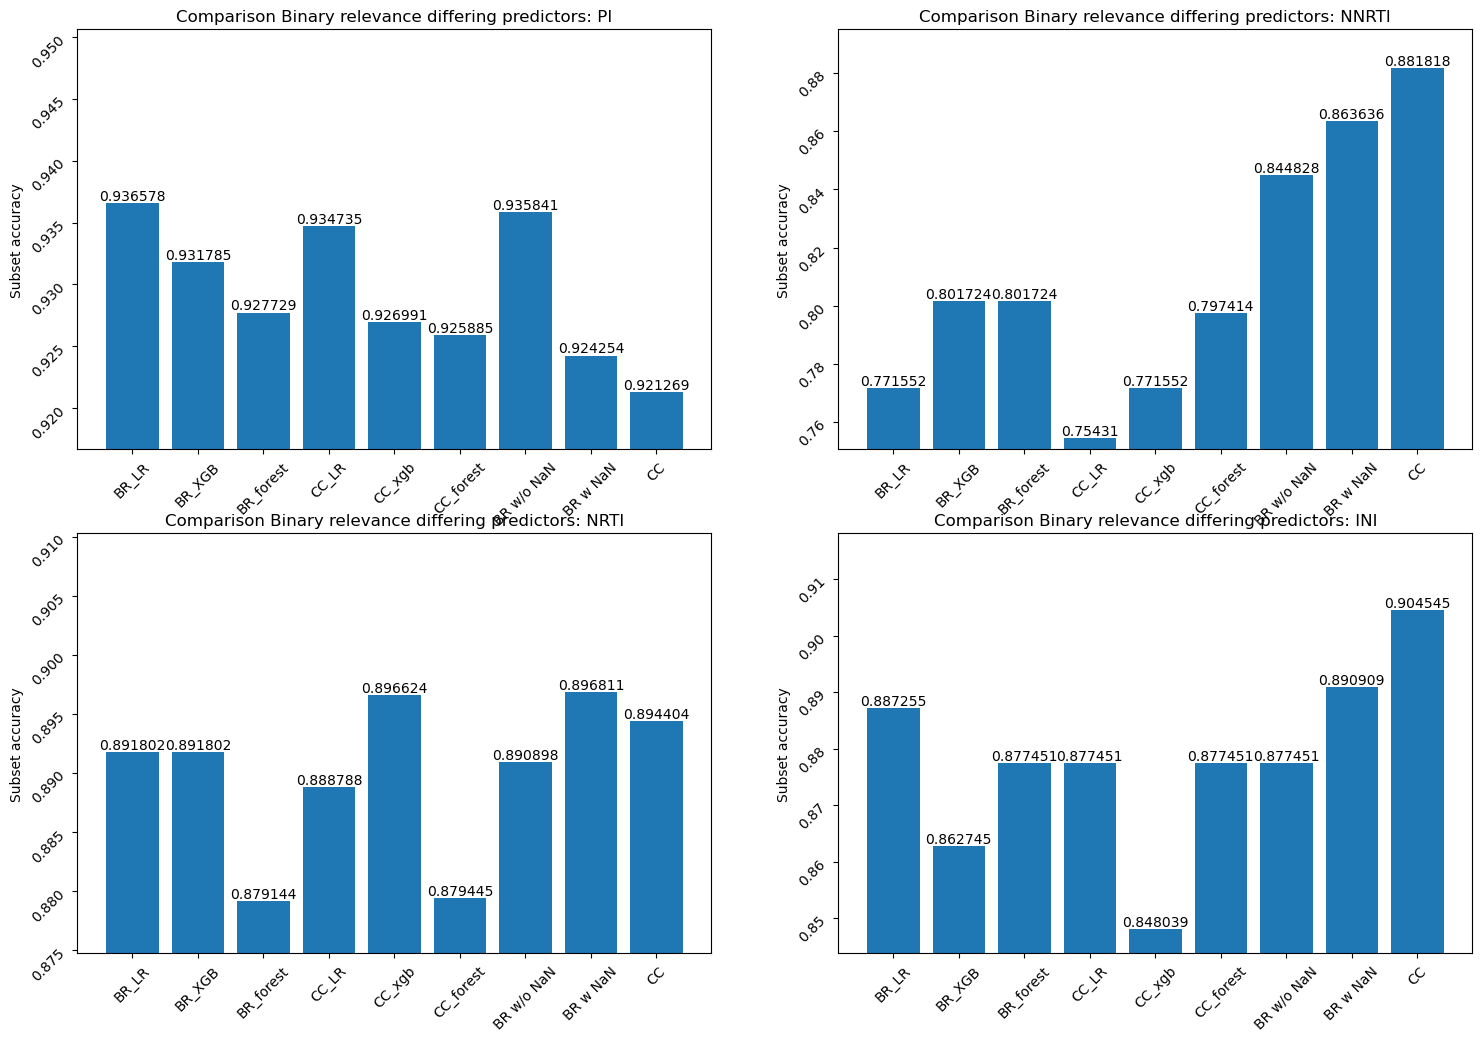

In [25]:
ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = ".csv"

sub_accs = {}

for path in filepath_list_ml:

    br_results = []
    cc_results = []
    #rakel_results = []

    for model in ml_models:
        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.exam_acc(pred_labels, true_labels)

        if model.startswith("BR"):
            br_results.append(sub_acc)
        elif model.startswith("CC"):
            cc_results.append(sub_acc)

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results]})

files = ["Binary_Relevance_MOC_prediction.csv", "Binary_Relevance_homebrew_prediction.csv", "Classifier_Chain_homebrew_prediction.csv"]

sub_accs_tabpfn = {}
jacc_macro = {}


for path in filepath_list:

    acc_list = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.exam_acc(true_labels, pred_labels)

        #print(jaccard_score(true_labels, pred_labels, average="samples"))
        #print(jaccard_score(true_labels, pred_labels, average="macro"))
        acc_list.append(sub_acc)

    sub_accs_tabpfn.update({path.split("/")[-1].strip("_"):acc_list})



df_sub_accs = pd.DataFrame(sub_accs)



models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(18, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):

    benchmarks = np.array(sub_accs[drug]).flatten()
    results = list(benchmarks) + sub_accs_tabpfn[drug]
    labels = ml_models + models_w_TabPFN
    p = axs[i].bar(labels, results)

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, min(results) * 0.995), min(1.0, max(results)  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)



#plt.savefig("../figures/BR_CC_comparison_woNaN.png")



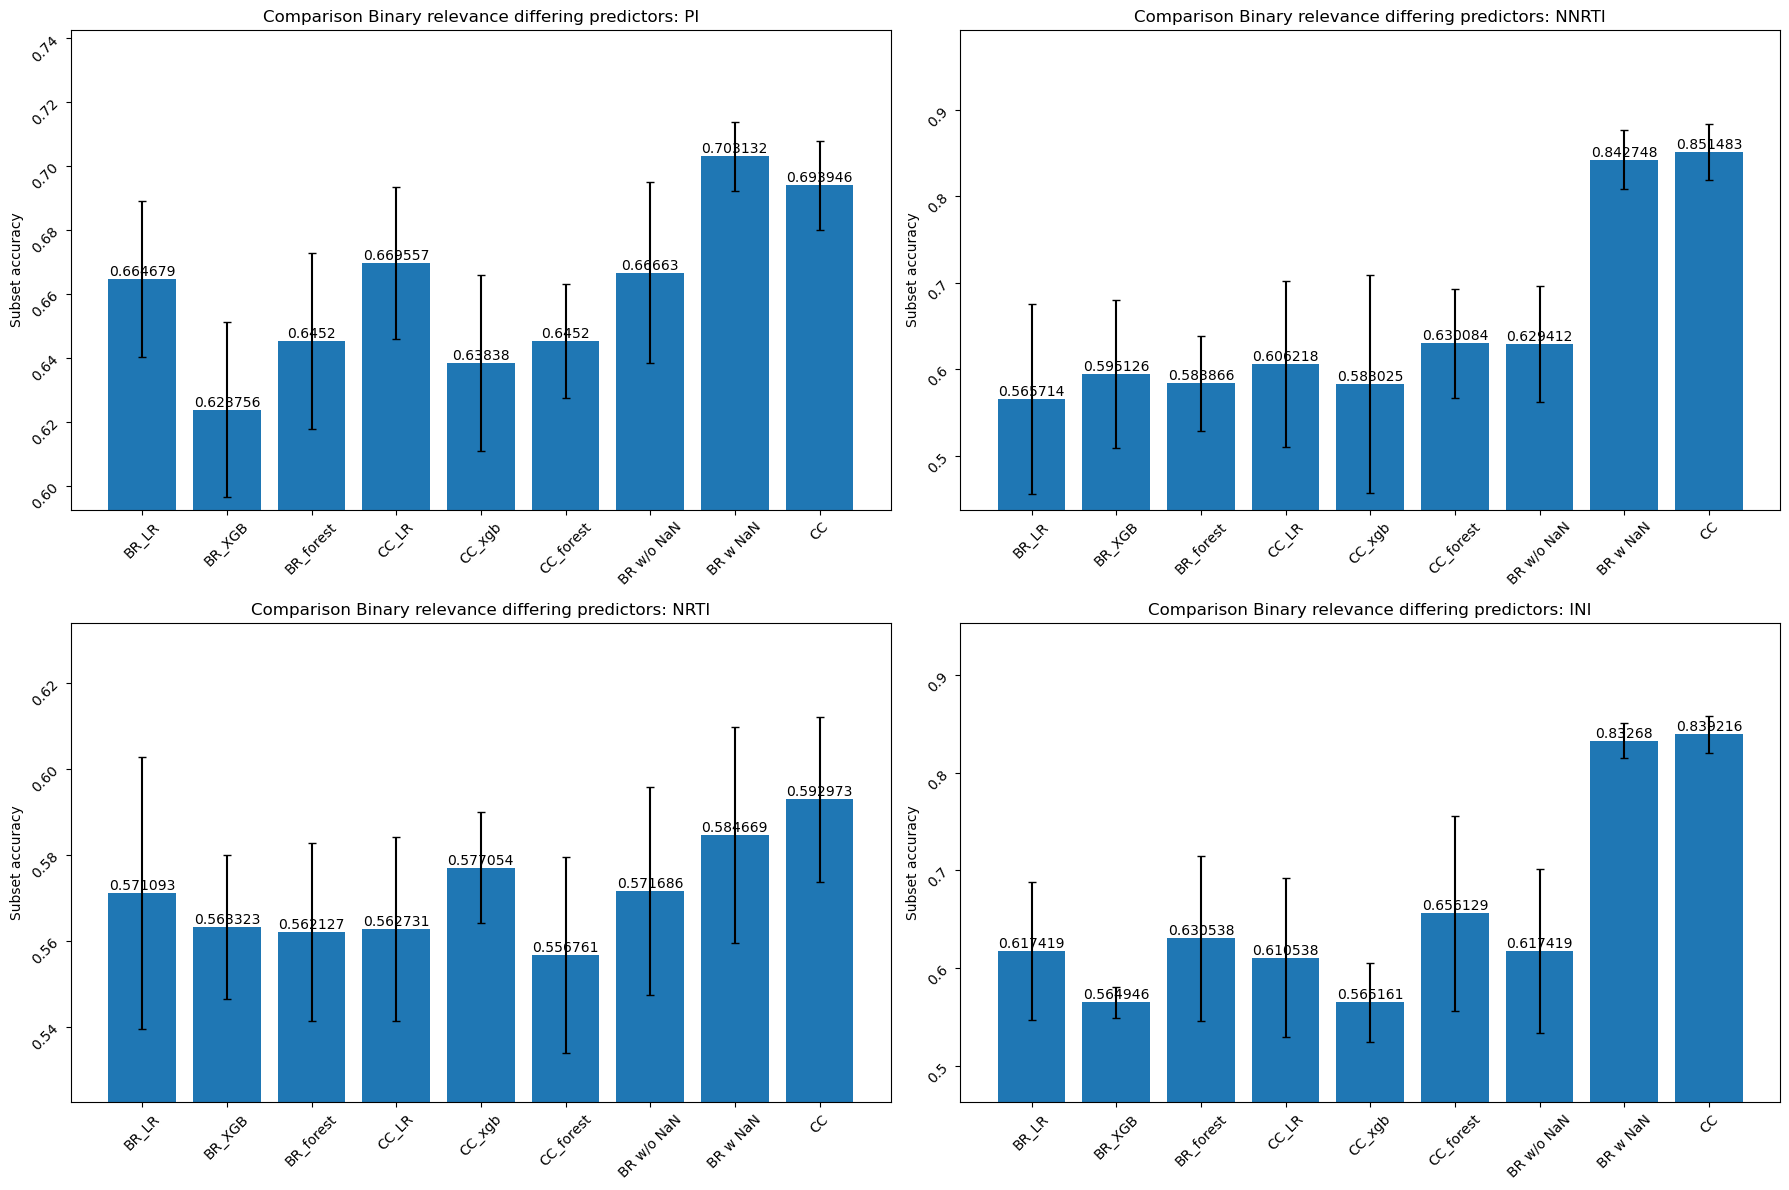

In [16]:
ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})



files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/BR_CC_benchmark_comparison.png")


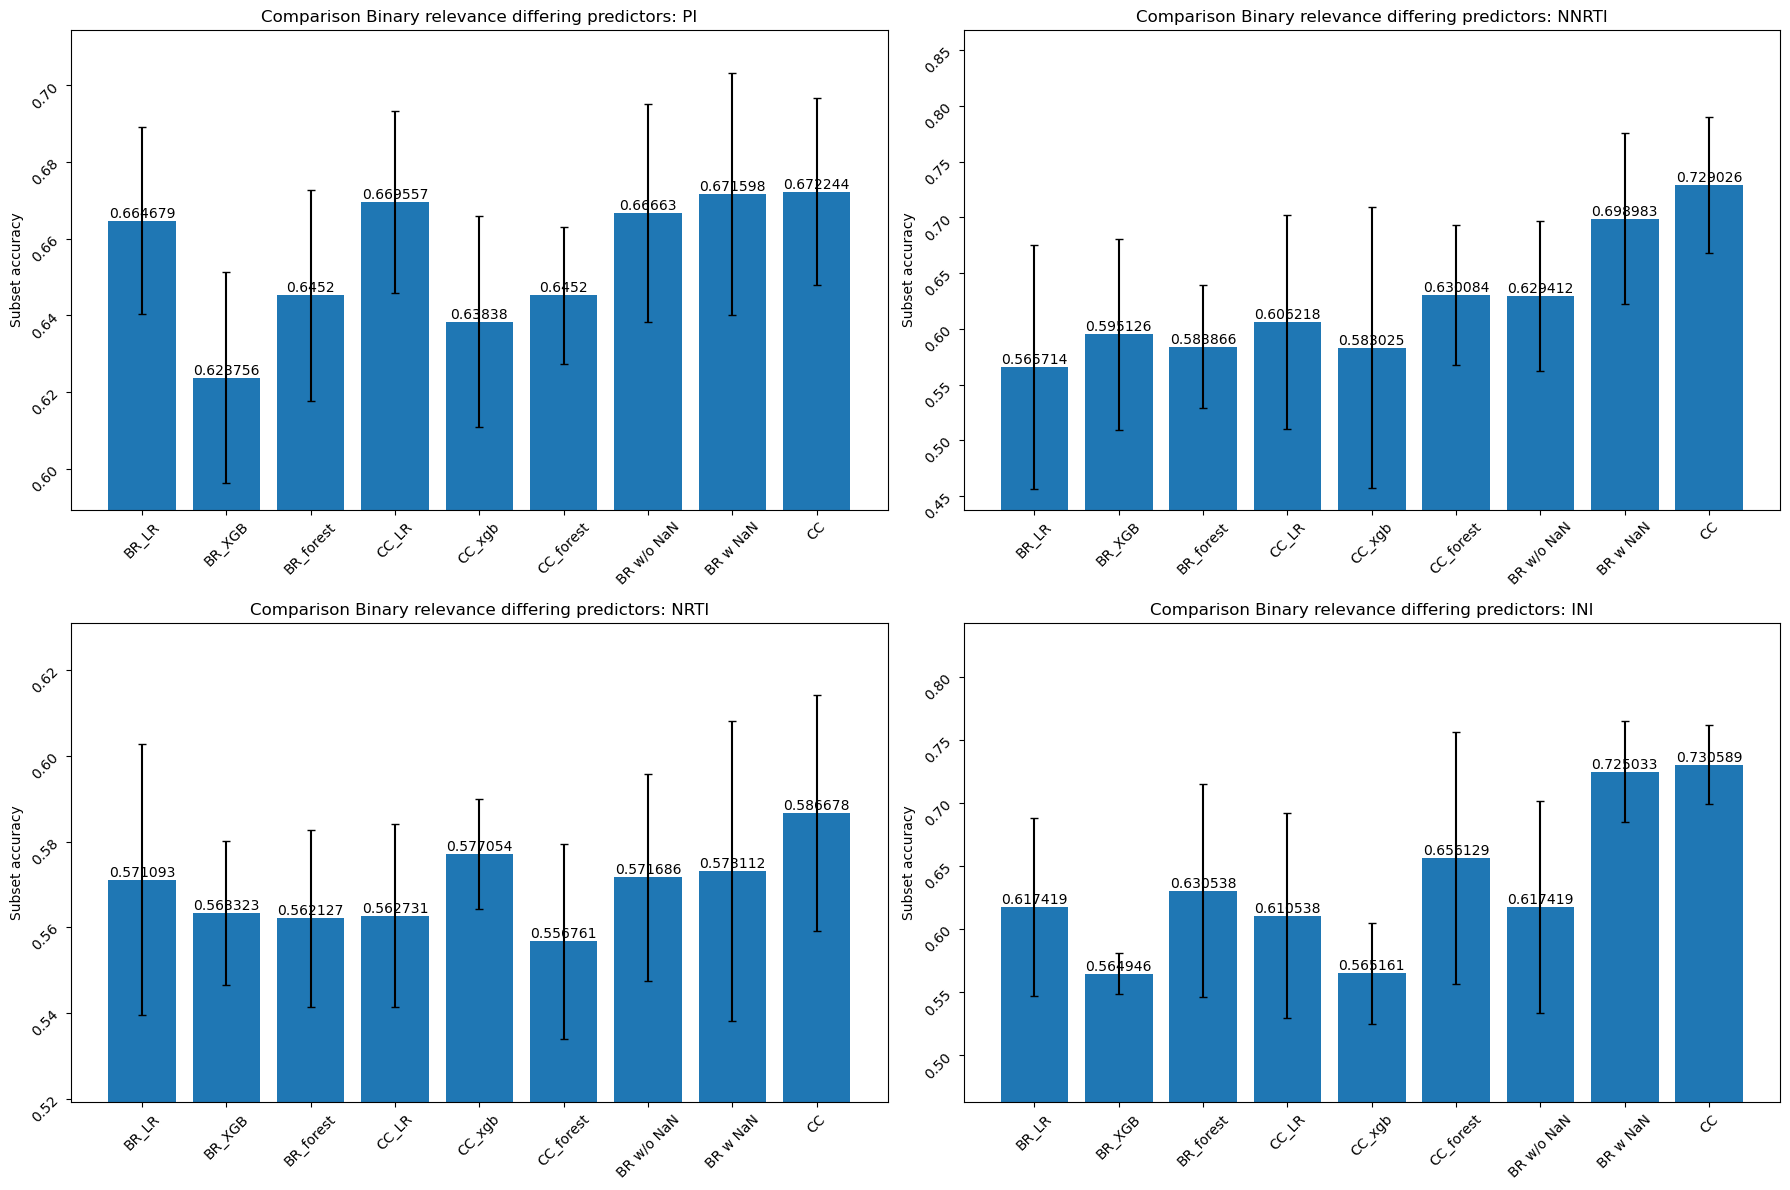

In [27]:
ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})



files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/BR_CC_benchmark_comparison_wo_NaN.png")


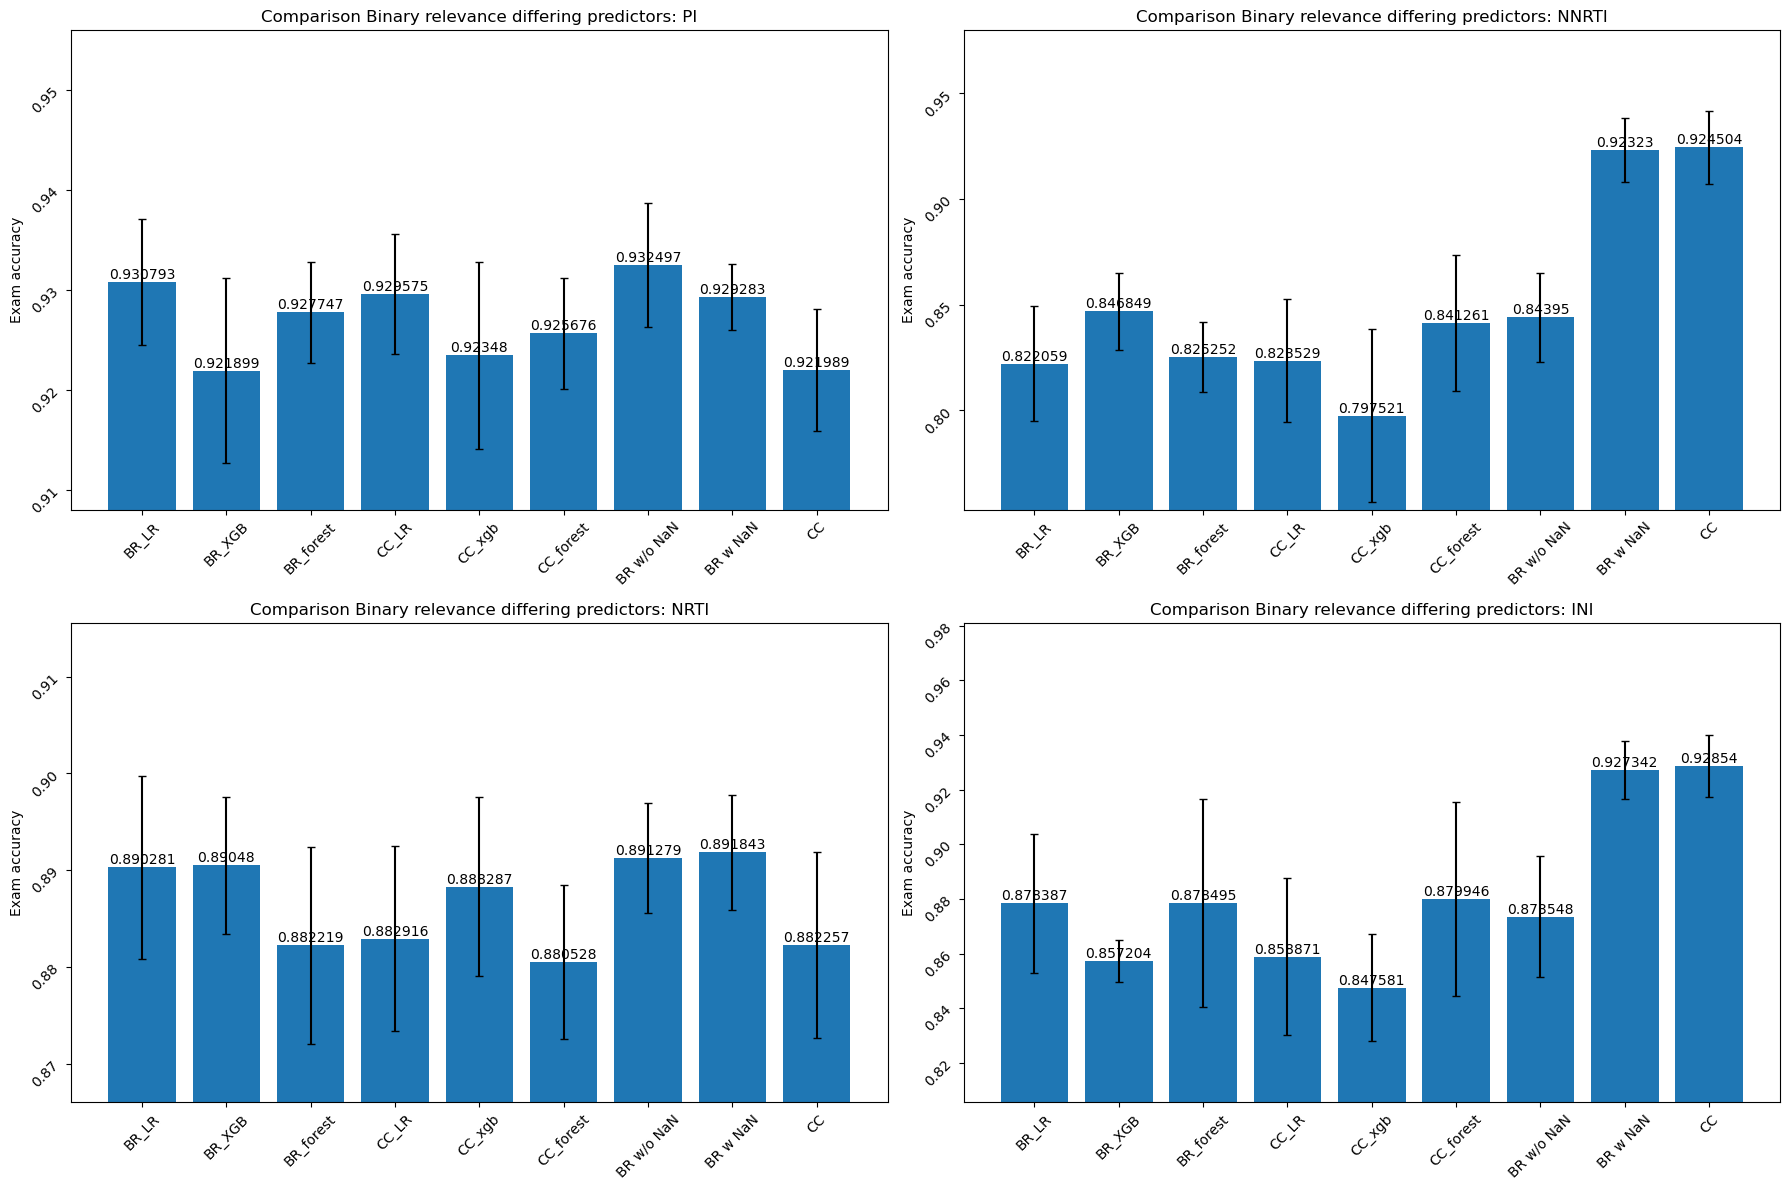

In [4]:
ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})



files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/BR_CC_benchmark_comparison_examAcc.png")


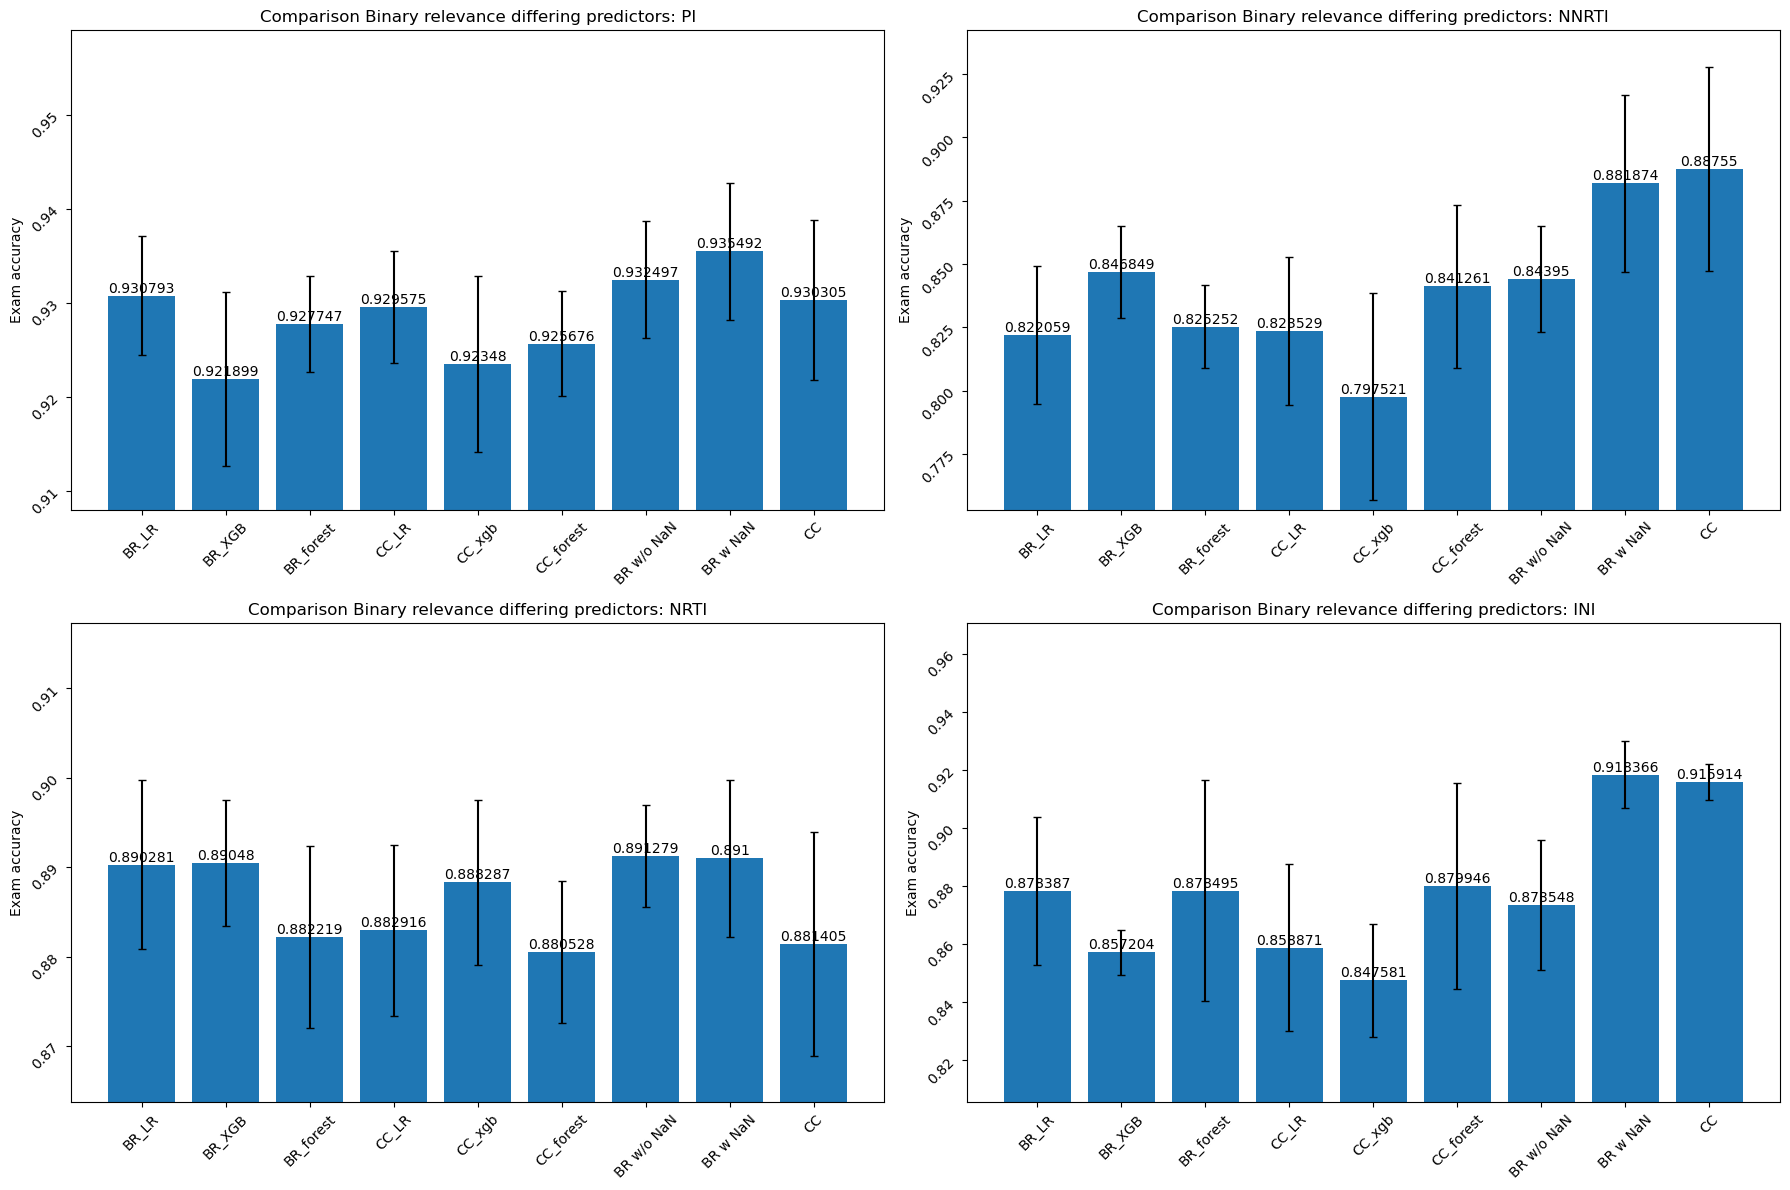

In [5]:
ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})



files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC"]

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/BR_CC_benchmark_comparison_examAcc_wo_NaN.png")


In [4]:
filepaths = [r"C:\Users\flori\Desktop\Masterarbeit\Models\prediction_results\PI_results\benchmarkings\PI_Rakel_lr.csv",r"C:\Users\flori\Desktop\Masterarbeit\Models\prediction_results\PI_results\benchmarkings\PI_Rakel_xgb.csv", r"C:\Users\flori\Desktop\Masterarbeit\Models\prediction_results\PI_results\benchmarkings\PI_Rakel_forest.csv"]

for filepath in filepaths:
    results = pd.read_csv(filepath)

    results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

    true_labels = results.filter(regex="True_*")
    pred_labels = results.filter(regex="Pred_*")

    sub_acc = utils.exam_acc(true_labels, pred_labels)

    print(sub_acc)

0.9339970501474927
0.9280973451327433
0.9277286135693216


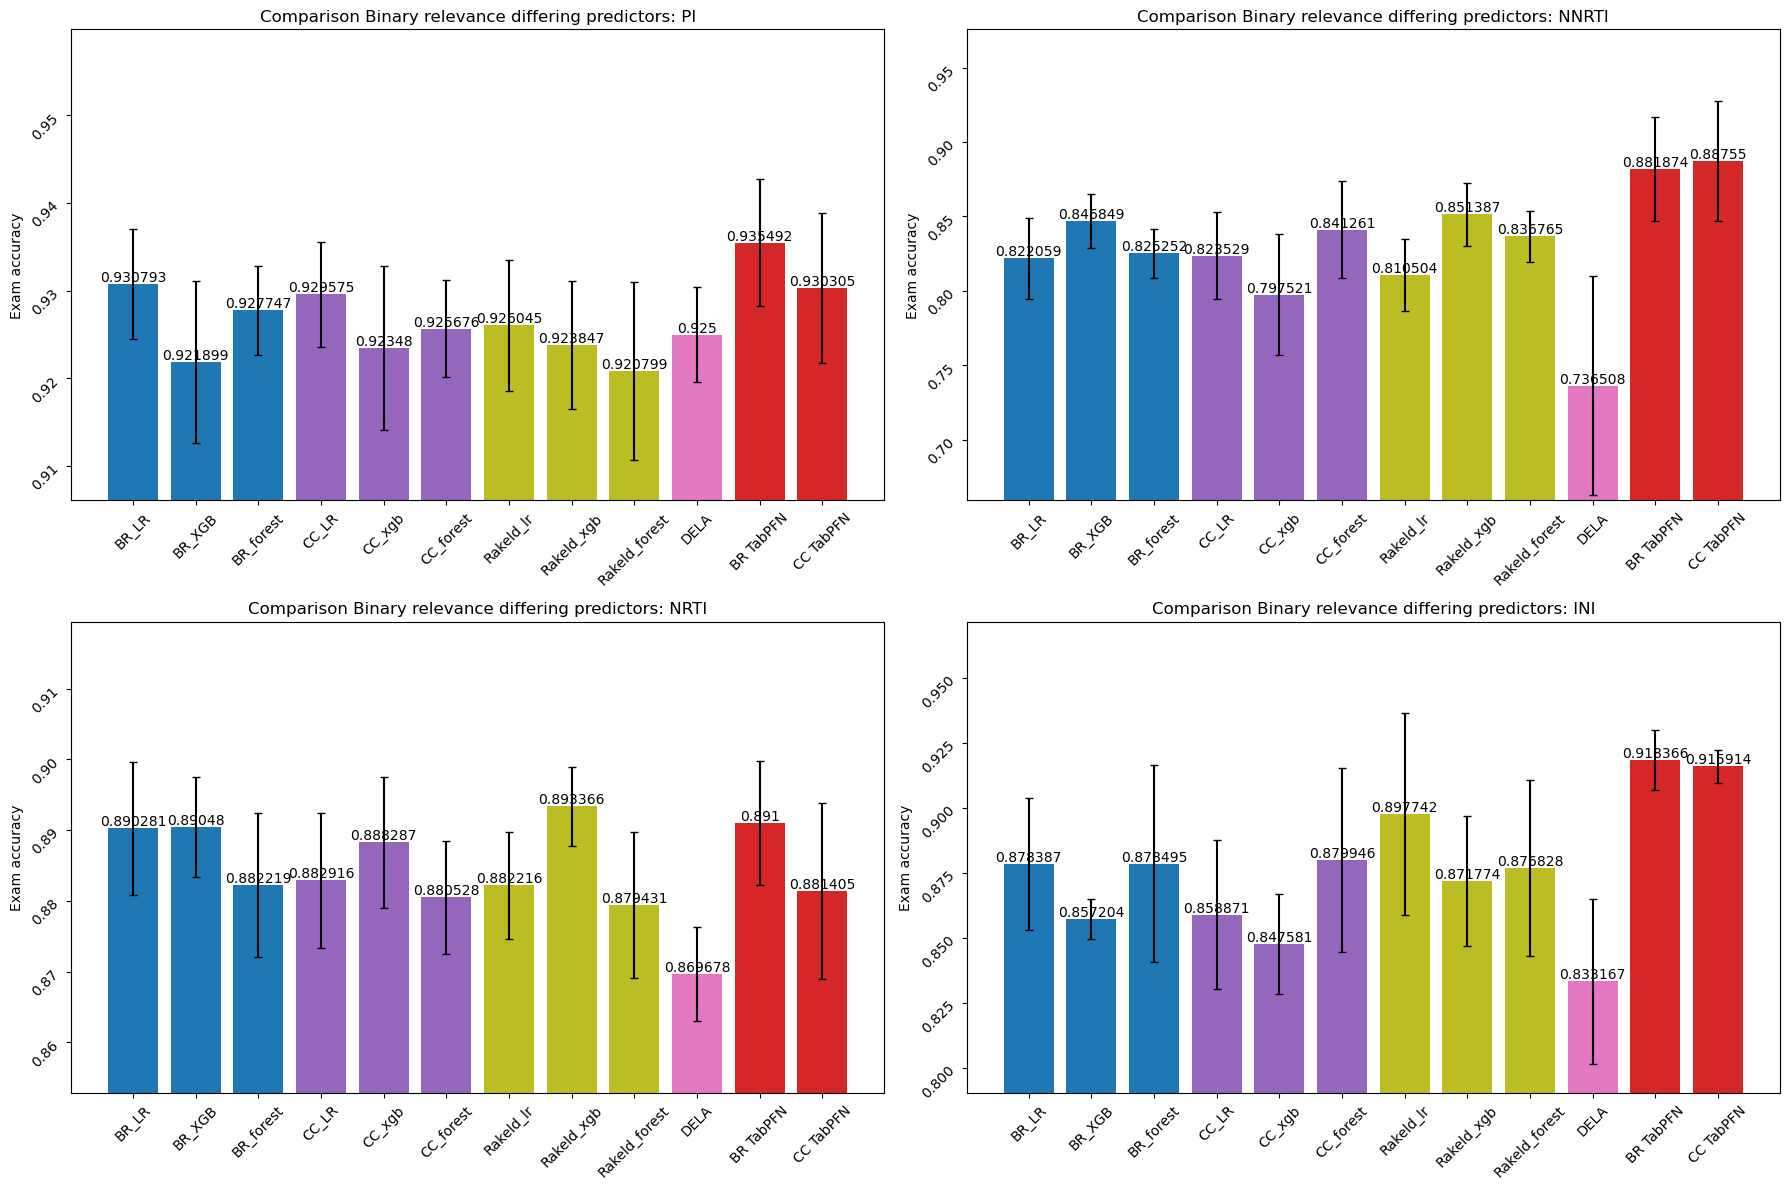

In [11]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})

files1 = ["Rakeld_lr", "Rakeld_xgb", "Rakeld_forest", "DELA"]

for path in filepath_list_ml:
    acc_list_mean = []
    acc_list_std = []

    for file in files1:
        results = pd.read_csv(path + file + ending)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


files = ["Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN", "CC TabPFN"]

color = ["tab:blue"] * 3 + ["tab:purple"] * 3 + ["tab:olive"] * 3 + ["tab:pink"] + ["tab:red"] * 2

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + files1 + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/All_benchmark_comparison_examAcc_wo_NaN.png")


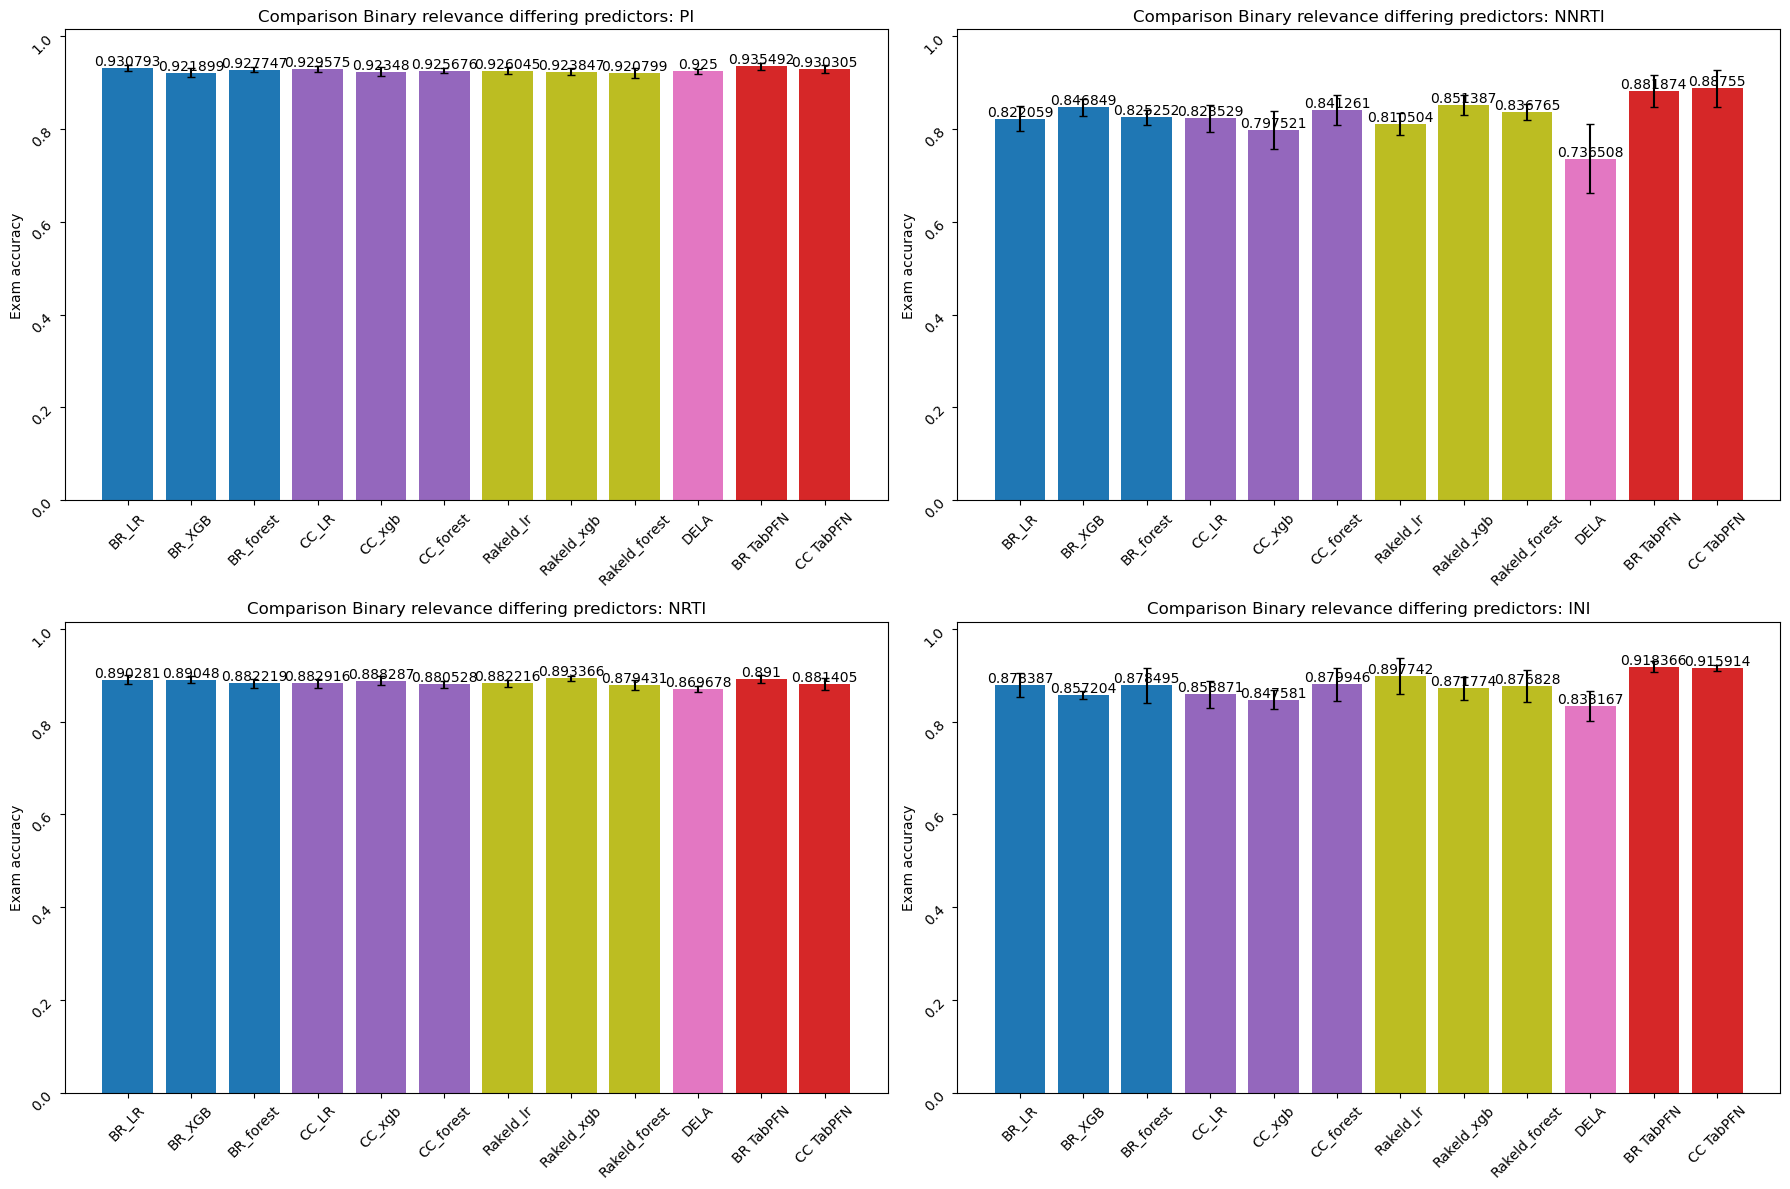

In [12]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})

files1 = ["Rakeld_lr", "Rakeld_xgb", "Rakeld_forest", "DELA"]

for path in filepath_list_ml:
    acc_list_mean = []
    acc_list_std = []

    for file in files1:
        results = pd.read_csv(path + file + ending)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


files = ["Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN", "CC TabPFN"]

color = ["tab:blue"] * 3 + ["tab:purple"] * 3 + ["tab:olive"] * 3 + ["tab:pink"] + ["tab:red"] * 2

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + files1 + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/All_benchmark_comparison_realScale_examAcc_wo_NaN.png")
